# Вычислительная математика
## 5.1 Краевая задача ОДУ

Содержание семинара:

- __Линейная краевая задача__
    - Формулировка
    - Обусловленность краевых условий
    - Методы решения линейной задачи
        - Метод ФСР 🥇
        - Метод дифференциальной прогонки 🥇
        - Метод линейной интерполяции*
    - Жесткость в краевых задачах
- __Нелинейная краевая задача__
    - Формулировка. Виды краевых условий
    - Методы решения нелинейной задачи
        - Метод стрельбы 🏹
        - Метод Ньютона 🏆
        - Метод Фурье 🌊
        - Метод Галёркина
        - Метод конечных элементов 😱

- __Аппроксимация граничных условий__
    - В чём проблема?
    - Методы аппроксимации гр. усл.
        - Метод одностороннего дифференциирования более высого порядка
        - Метод фиктивной ячейки
        - Метод ряда Тейлора
- __Задача Штурма-Лиувилля*__
-  __Домашнее задание__

## Линейная краевая задача
### Формулировка

Пусть имеем следующую ОДУ 1-го порядка:

$$
\frac{d \mathbf{y}}{d x}=\hat{\mathbf{A}}(x) \cdot \mathbf{y}+\mathbf{f}(x)
$$

где $x \in[0, X], \; \mathbf{y}, \mathbf{f}-n$-мерные векторы, $\; \hat{\mathbf{A}}(x) \in \mathbb{R}^{n \times n}$

Для существования единственного решения необходимо также задать $n$  __граничных условий__:

$$
\hat{\mathbf{L}} \cdot \mathbf{y}(0)+\hat{\mathbf{R}} \cdot \mathbf{y}(X)=\mathbf{g}, \quad \hat{\mathbf{L}}, \hat{\mathbf{R}} \in \mathbb{R}^{n \times n}, \quad \mathbf{g} \in \mathbb{R}^n
$$

По сути, здесь просто записано $n$ уравнений на граничные точки в хитром виде. Как правило, условия пишутся гораздо проще.

__Пример.__ Сведём следующее ДУ к виду выше
$$
\begin{aligned}
& y^{\prime \prime}+q(x) y^{\prime}-p(x) y=f(x), \quad 0<x \leq 1 \\
& y(0)=Y_0, \quad y(1)=Y_1
\end{aligned}
$$

Для того чтобы свести дифференциальное уравнение к матричному виду, мы можем использовать следующее представление:
$$
\mathbf{y}^{\prime}=\left(\begin{array}{c}
y^{\prime} \\
y^{\prime \prime}
\end{array}\right), \quad \mathbf{y}=\left(\begin{array}{c}
y \\
y^{\prime}
\end{array}\right), \quad \hat{\mathbf{A}}(x)=\left(\begin{array}{cc}
0 & 1 \\
-p(x) & q(x)
\end{array}\right), \quad \mathbf{f}(x)=\left(\begin{array}{c}
0 \\
f(x)
\end{array}\right) 
$$
Тогда исходное уравнение можно записать в виде
$$
\mathbf{y}^{\prime}=\hat{\mathbf{A}}(x) \mathbf{y}+\mathbf{f}(x), \quad \mathbf{y}(0)=\left(\begin{array}{c}
Y_0 \\
?
\end{array}\right), \quad \mathbf{y}(1)=\left(\begin{array}{c}
Y_1 \\
?
\end{array}\right)
$$

Видим, что у нас есть два краевых условия. Т.е. задача корректно поставлена.

Отметим, что иногда бывает удобно не приводить к виду системы и решать линейное ДУ непосредственно.

## Линейная краевая задача
### Обусловленность краевых условий

C точки зрения вычислений также важно, чтобы матрица была хорошо обусловленной. Рассмотрим случай, когда матрица $\hat{\mathbf{A}}(x)$ имеет $n$ действительных собственных значений, из них:

1) $n_1$  очень больших положительных: $\max \lambda_i \cdot L \gg 1$;
2) $n_2$  очень больших отрицательных: $\min \lambda_i \cdot L \ll -1$;
3) Все остальные умеренной величины $\left|\lambda_i\right| \cdot L \simeq 1$.

Это означает, что точное решение представляется в виде $n_1$ сильно затухающих экспонент и $n_2$ сильно возрастающих экспонент. 

Для корректности разрешения системы уравнений краевых условий необходимо, чтобы __не менее $n_1$ условий были поставлены слева__ и __не менее $n_2$ условий справа__. Это обусловлено тем, что наши методы, как правило, неустойчивы для быстровозрастающих экспонент, но если их начальные условия заданы "справа", то идя влево они как бы убывают.

Для слабо возрастающих или слабо убывающих компонент краевые условия могут быть поставлены на любом из концов отрезка.

## Линейная краевая задача
### Методы. Фундаментальная система решений 🥇

Т.к. задача линейная

$$
\frac{d \mathbf{y}}{d x}=\hat{\mathbf{A}}(x) \cdot \mathbf{y}+\mathbf{f}(x)
$$

$$
\hat{\mathbf{L}} \cdot \mathbf{y}(0)+\hat{\mathbf{R}} \cdot \mathbf{y}(X)=\mathbf{g}
$$

То общее решение является суммой частного неоднородного и общего однородного (ФСР):

$$
\mathbf{y}(x)=\overline{\mathbf{y}}(x)+\sum_{k=1}^n \alpha_k \mathbf{y}^k
$$

Здесь $\mathbf{y}^k(x)$ есть полная фундаментальная система решений однородной задачи с заданными нами начальными данными, например:

$$
\frac{d \mathbf{y}^k}{d x}=\mathbf{A}(x) \cdot \mathbf{y}^k, \quad k=1,2, \ldots, n
$$

$$
\mathbf{y}^k(0)=(0, \ldots, 0,1,0, \ldots, 0)^{\mathrm{T}}
$$

Т.е. для их нахождения нужно решить $n$ задач Коши, которые мы уже умеем решать. Например, Рунге-Куттой.

Выберем также такое частное решение, что оно удовлетворяет задаче Коши с нулевыми начальными условиями:

$$
\frac{d \overline{\mathbf{y}}}{d x}=\mathbf{A} \overline{\mathbf{y}}+\mathbf{f}(x)
$$

$$
\overline{\mathbf{y}}(0) = \vec{0}
$$

Осталось лишь подобрать коэффициенты $\alpha_k$, чтобы полученное нами общее решение удовлетворяло краевым условиям. Просто подставим наше общее решение в уравнение на краевые условия:

$$
\mathbf{R}\left[\sum_{k=1}^n \alpha_k \mathbf{y}^k(0)\right]+\mathbf{L} \overline{\mathbf{y}}(X)+\mathbf{L}\left[\sum_{k=1}^n \alpha_k \mathbf{y}^k(X)\right]=\mathbf{g}
$$

Для однозначной разрешимости этого уравнения при произвольных краевых условиях, достаточно линейной независимости векторов при варьируемых $\alpha_k$:

$$
\operatorname{det}\left(\begin{array}{c}
\mathbf{R y}^1(0)+\mathbf{S y ^ { 1 } ( L )} \\
\cdots \\
\mathbf{R y}^n(0)+\mathbf{S y ^ { n } ( L )}
\end{array}\right) \neq 0
$$

Здесь каждый вектор в строке необходимо дополнительно транспонировать, чтобы получилась матрица.

Это условие __не обязано__ всегда выполняться, то есть даже в линейном случае могут встретиться такие постановки задачи, что решение либо __не существует__, либо __не единственное__, если матрица СЛАУ для коэффициентов вырожденная. 

Более того, если в спектре матрицы $\hat{\mathbf{A}}(x)$ есть большие положительные собственные числа, мы не сможем решить задачу Коши из-за неустойчивости. Поэтому вполне себе можно находить общие решения однородного решая краевую задачу для них каким-нибудь другим способом (см. ниже).

Таким образом, метод ФСР прост и хорош, но есть нюансы.

## Линейная краевая задача
### Методы. Метод дифференциальной прогонки 🥇

Проиллюстрируем этот метод на конкретном примере. Все выкладки легко перенести на произвольный линейный случай, но почему-то в литературе никто этого не сделал ;\

Имеем уравнение из примера:

$$
\begin{aligned}
& y^{\prime \prime}+q(x) y^{\prime}-p(x) y=f(x), \quad 0<x \leq 1 \\
& y(0)=Y_0, \quad y(1)=Y_1
\end{aligned}
$$

Перепишем это уравнение в виде следующей системы (естественно, это можно сделать не единственным способом)

$$
\left\{\begin{aligned}
& \frac{d y}{d x}=a(x) v+b(x) \\
& \frac{d v}{d x}=c(x) y+g(x)
\end{aligned} \right .
$$

И будем искать решение в виде т.н. __прогоночного соотношения__:

$$
y(x)=\alpha(x) v(x)+\beta(x)
$$

где $\alpha(x)$ и $\beta(x)$ - пока неизвестные функции (__прогоночные коэффициенты__), для которых необходимо получить дифференциальные уравнения.

Тогда, решение можно найти, решив следующие 3 задачи Коши в соответствующем порядке:

$$
\begin{aligned}
& \alpha^{\prime}(x)+c \cdot \alpha^2(x)-a=0, \quad \alpha(0)=0 \\ \\
& \beta^{\prime}(x)+\alpha \cdot \beta (x) \cdot c+\alpha \cdot g-b=0, \quad \beta(0)=Y_0\\ \\
& v^{\prime}(x)=\alpha \cdot c \cdot v(x)+c \cdot \beta+g, \quad v(1)=\cfrac{Y_1 - \beta(1)}{\alpha(1)}
\end{aligned}
$$

Метод очень хорош для нежестких задач.

__Доказательство__

Продифференцируем это соотношение



$$
y^{\prime}=\alpha^{\prime} v+\alpha v^{\prime}+\beta^{\prime}
$$

и подставим в него уравнения системы 

$$
\left\{\begin{aligned}
& y^{\prime}=a v+b \\
& v^{\prime}=c y+g
\end{aligned} \right .
$$

В результате получим, что $a v+b=\alpha^{\prime} v+\alpha(c y+g)+\beta^{\prime}$. Подставим в полученное равенство прогоночное соотношение $y=\alpha v+\beta$. 

Тогда

$$
a v+b=\alpha^{\prime} v+\alpha^2 c v+c \beta+\alpha g+\beta^{\prime} v+\beta .
$$

После приведения подобных членов имеем равенство

$$
v\left(\alpha^{\prime}+c \alpha^2-a\right)+\left(\beta^{\prime}+c \beta \alpha+\alpha g-b\right)=0 .
$$

Приравнивая к нулю коэффициенты при $v$ и единице, получим __два дифференциальных уравнения для прогоночных коэффициентов__:

$$
\left \{\begin{aligned}
& \alpha^{\prime}+c \alpha^2-a=0 \\
& \beta^{\prime}+\alpha \beta c+\alpha g-b=0
\end{aligned} \right .
$$

Дополним их начальными условиями. 

- Условия слева

Левое краевое условие вида $y(0)=Y_0$ запишем в виде прогоночного соотношения $y(0)=\alpha(0) v(0)+\beta(0)$, полагая $\alpha(0)=0, \quad \beta(0)=Y_0$. 

Таким образом, получаем начальные данные для двух задач Коши для $\alpha(x)$ и $\beta(x)$, которые могут быть решены численно.

- Условия справа

Их просто подгоним из равенства граничных условий справа.

Далее воспользуемся уравнением $v^{\prime}=c y+g$, подставим в него прогоночное соотношение $y=\alpha v+\beta$, получим дифференциальное уравнение для $v:$

$$
v^{\prime}(x)=\alpha \cdot c \cdot v(x)+c \cdot \beta+g, \quad v(1)=\cfrac{Y_1 - \beta(1)}{\alpha(1)}
$$

## Линейная краевая задача
### Методы. Метод линейной интерполяции*

Рассмотрим смешанную краевую задачу для уравнения

 $$
 y^{\prime \prime}+p(x) y^{\prime}+q(x) y+f(x)=0, \quad 0<x<l 
 $$

Граничные условия возьмем в смешанном виде

$$
\begin{gathered}
y(0)=a, \\
y^{\prime}(l)+\alpha y(l)=b .
\end{gathered}
$$  

Выберем любые два значения $\lambda=\lambda_{1}, \;\lambda=\lambda_{2}$ и решим две задачи Коши с начальными условиями:

$$
\begin{aligned}
&y_{1}(0)=a, \quad  y_{1}^{\prime}(0)=\lambda_{1} \\
&y_{2}(0)=a, \quad  y_{2}^{\prime}(0)=\lambda_{2}
\end{aligned}
$$

Полученные решения обозначим как $y=y_{1}(x)$ и $y=y_{2}(x)$. Найдем соответствующие значения левых частей в граничном условии.  

\begin{aligned}
&y_{1}^{\prime}(l)+\alpha y_{1}(l)=b_{1} \\
&y_{2}^{\prime}(l)+\alpha y_{2}(l)=b_{2}
\end{aligned}

Теперь значение недостающего начального условия $y^{\prime}(0)=\lambda$ можно найти с помощью линейной интерполяции:

$$
\frac{\lambda-\lambda_{1}}{\lambda_{2}-\lambda_{1}}=\frac{b-b_{1}}{b_{2}-b_{1}} \quad \text {, T.e. } \lambda=\lambda_{1}+\left(\lambda_{2}-\lambda_{1}\right) \frac{b-b_{1}}{b_{2}-b_{1}} .
$$

Полученное значение $\lambda$ и будет являться недостающим начальным условием. Объясняется это линейностью задачи. Как известно, дифференциальное уравнение имеет общее решение

$$
y(x)=c_{1} u_{1}(x)+c_{2} u_{2}(x)+y_{n}(x),
$$

где $u_{1}(x)$ и $u_{2}(x)$ - линейно-независимые решения однородного уравнения (при $f(x) \equiv 0)$, а $y_{n}(x)$ - какое-либо решение неоднородного уравнения (частное решение неоднородного уравнения). Удовлетворяя левому граничному условию, в общем решении останется одна неизвестная постоянная, которая входит в выражение для $y(x)$ линейным образом. Проведя в плоскости $(\lambda, b)$ прямую, проходящую через две точки $\left(\lambda_{1}, b_{1}\right)$ и $\left(\lambda_{2}, b_{2}\right)$ при заданном значении $b$ мы однозначно найдем точное значение $\lambda$.  

Теперь таблицу значений функции $y(x)$ (и ее производной) можно найти интерполяцией $y(x)=y_{1}(x)+\left[y_{1}(x)-y_{1}(x)\right] \cdot \frac{\lambda-\lambda_{1}}{\lambda_{2}-\lambda_{1}}$.

Однако на практике, жертвуя машинным временем, обычно проводят третий расчет задачи Коши с условиями
$$
y(0)=a, \quad y^{\prime}(0)=\lambda .
$$

__Замечание.__

 На практике обычно выбирают простейшие значения $\lambda$, например $\lambda_{1}=1$ и $\lambda_{2}=0$. При этом, если само уравнение является однородным, т.е. $f(x) \equiv 0$, и граничное условие так же однородное, $y(0)=0$, то решение имеет вид $y_{2}(x) \equiv 0, b_{2}=0$. Тогда второй расчет (при $\lambda_{2}=0$ ) нет необходимости производить и формула даст ответ в виде

$$
\lambda=\lambda_{1} \frac{b}{b_{1}} .
$$

Поэтому, если предложено решить однородное уравнение, то следует посмотреть, есть ли однородное граничное условие и если оно есть, то начинать расчет следует от этой границы! Эта рекомендация остается в силе и для других методов решения краевых задач.

## Линейная краевая задача
### Жесткость в краевых задачах

Рассмотрим краевую задачу:

$$
\frac{d \mathbf{y}}{d x}=\mathbf{A}(x) \cdot \mathbf{y}+\mathbf{f}, \quad x \in[a, b]
$$

с граничными условиями в следующем виде:

$$
\hat{\mathbf{L}} \cdot \mathbf{y}(0)+\hat{\mathbf{R}} \cdot \mathbf{y}(X)=\mathbf{g}, \quad \hat{\mathbf{L}}, \hat{\mathbf{R}} \in \mathbb{R}^{n \times n}, \quad \mathbf{g} \in \mathbb{R}^n
$$


__Определение 1.__ Краевая задача  является __жесткой__, если спектр собственных значений матрицы $\hat{\mathbf{A}}(x)$ можно разделить на три части:
1. Левый жесткий спектр, для которого выполняется $\operatorname{Re} \Lambda_i^1 \leq-\Lambda_0$, $\left|\operatorname{Im} \Lambda_i^1\right|<\Lambda_0, \Lambda_0(b-a) \gg 1, \Lambda_0 \gg 1, \quad i=1, \ldots, N_1$
2. Правый жесткий спектр, для которого $\operatorname{Re} \Lambda_i^2 \geq \Lambda_0, \quad\left|\operatorname{Im} \Lambda_i^2\right|<\Lambda_0$, $i=N_1+1, \ldots, N_2$
3. Мягкий спектр $\left|\lambda_i\right| \leq \lambda_0, \quad \lambda_0(b-a) \simeq O(1), i=N_2+1, \ldots, N$.

Отношение $\Lambda_0 / \lambda_0 \sim 1$ называется параметром, характеризующим жесткость системы.

Общее решение жесткой линейной системы ОДУ с постоянными коэффициентами имеет вид

$$
\mathbf{y}(x)=\sum_{i=1}^{N_1} \gamma_i^1 e^{\Lambda_i^1 x} \boldsymbol{\Omega}_i^1+\sum_{i=N_1+1}^{N_2} \gamma_i^2 e^{\Lambda_i^2 x} \boldsymbol{\Omega}_i^2+\sum_{i=N_2+1}^N \gamma_i^3 e^{\lambda_i x} \boldsymbol{\omega}_i
$$

где $\boldsymbol{\Omega}_i^1, \boldsymbol{\Omega}_i^2, \boldsymbol{\omega}_i-$ собственные векторы матрицы $\mathbf{A}$, соответствующие трем частям спектра.

Понятна качественная структура этого решения, содержащего и левый, и правый пограничные слои. Для решений жестких линейных краевых задач должно быть выполнено неравенство $\|\mathbf{y}\| \leq \mathrm{C}(\|\mathbf{f}\|+\|\mathbf{g}\|)$, $\|\mathbf{f}\|$ и $\|\mathbf{g}\|$ - нормы правых частей в системе ОДУ и краевых условиях соответственно. 

Правильно работать только в классе __вычислительно корректных задач__, для которых $C=O(1)\ll\exp \left(\Lambda_0(b-a)\right)$.

Для вычислительной корректности (почти) достаточно, чтобы число краевых условий на левом конце отрезка интегрирования не было меньше быстро убывающих вправо решений, на правом конце - не меньше числа быстро убывающих решений влево.

В противном случае краевая задача оказывается вычислительно некорректной, так как $C=O\left(\exp \left(\Lambda_0(b-a)\right)\right)$.

## Нелинейная краевая задача
### Формулировка. Виды краевых условий.

Всё, о чём будем здесь говорить, применимо и к линейным задачам, но сами понимаете, это как из пушки по воробьям.

__Определение.__ Краевая задача
$$
\begin{aligned}
& y^{\prime \prime}=f\left(x, y, y^{\prime}\right), \quad 0<x \leq 1, \\
& y(0)=Y_0, \quad y(1)=Y_1
\end{aligned}
$$
является __нелинейной краевой задачей__, если функция $f\left(x, y, y^{\prime}\right)$ нелинейна хотя бы по одному из аргументов $y$ или $y^{\prime}$.

__Виды граничных условий.__ 

- Тип 1 - условия разделены на левые и правые и не используются производные.
- Тип 2 - есть условия на производные, но левая и правая части разделены.
- Тип 3 - условия смешанные.

## Нелинейная краевая задача
### Методы. Метод стрельбы 🏹

Хотим решить __краевую задачу__

$$
\begin{aligned}
& y^{\prime \prime}=f\left(x, y, y^{\prime}\right), \quad 0<x \leq 1, \\
& y(0)=Y_0, \quad y(1)=Y_1
\end{aligned}
$$

Пусть умеем решать __задачу Коши__ для произвольного __пристрелочного параметра__ $\alpha$:

$$
\begin{aligned}
& y^{\prime \prime}=f\left(x, y, y^{\prime}\right), \quad 0<x \leq 1, \\
& y(0)=Y_0, \quad y^{\prime}(0)=\alpha
\end{aligned}
$$

Обозначим решение этой задачи Коши как $y_\alpha(x)$

Наша цель - __найти__ такой $\alpha = \alpha^*$, что полученное решение удовлетворяет изначальным краевым условиям. Иначе, хотим найти ноль следующей функции:

$$
F(\alpha)=y_\alpha(1)-Y_1
$$

$$
F(\alpha^*)=0
$$

Это можно делать с помощью любого алгоритма поиска нуля численно заданной функции (см. решение нелинейных уравнений), например, дихотомией или итерацией по Ньютону:

$$
\alpha_{n+1}=\alpha_n-\frac{F\left(\alpha_n\right)}{F^{\prime}\left(\alpha_n\right)}
$$

$$
F^{\prime}\left(\alpha_n\right)\approx\frac{F\left(\alpha_n+h\right)-F\left(\alpha_n\right)}{h}
$$

## Нелинейная краевая задача
### Методы. Метод Ньютона

Метод Ньютона сводит решение нелинейной краевой задачи к решению __серии линейных краевых задач__ и состоит в следующем.

Пусть для нелинейной краевой задачи известна функция $y_0(x)$, удовлетворяющая граничным условиям и __грубо равная__ искомому $y(x)$. Положим

$$
y(x)=y_0(x)+v(x)
$$

где $v(x)$ - поправка к нулевому приближению $y_0(x)$. 

В предположении о малости поправки имеем:

$$
\begin{aligned}
 y^{\prime \prime}(x)=y_0^{\prime \prime}(x)+v^{\prime \prime}(x) \\
 f\left(x, y_0+v, y_0^{\prime}+v^{\prime}\right)= &f\left(x, y_0, y_0^{\prime}\right)
+\frac{\partial f\left(x, y_0, y_0^{\prime}\right)}{\partial v} v+ \\&+\frac{\partial f\left(x, y_0, y_0^{\prime}\right)}{\partial v^{\prime}} v^{\prime}+O\left(v^2+\left|v^{\prime}\right|^2\right)
\end{aligned}
$$

Отбрасывая остаточный член $\mathrm{O}\left(v^2+\left|v^{\prime}\right|^2\right)$, получим __линейную краевую задачу__ для нахождения поправки $\tilde{v}(x)$ с нулевыми краевыми условиями:

$$
\left \{\begin{aligned}
& \tilde{v}^{\prime \prime}=p(x) \cdot \tilde{v}^{\prime}+g(x) \cdot \tilde{v}+r(x), \\
& \tilde{v}(0)=0, \quad \tilde{v}(1)=0
\end{aligned} \right .
$$

где

$$
\begin{aligned}
& p(x)=\frac{\partial f\left(x, y_0, y_0^{\prime}\right)}{\partial y^{\prime}}, \quad q(x)=\frac{\partial f\left(x, y_0, y_0^{\prime}\right)}{\partial y}, \\
& r(x)=f\left(x, y_0, y_0^{\prime}\right)-y_0^{\prime \prime} 
\end{aligned}
$$

Решая эту линейную краевую задачу каким-либо численным методом, найдем поправку $\widetilde{v}$ и примем за первое приближение

$$
y_1(x) \equiv y_0(x)+\tilde{v} .
$$

Осталось только продолжить этот процесс до тех пор, пока не будут выполнено неравенство на норму ошибки

$$
\max |\tilde{v}(x)| \leq \varepsilon, \quad x \in[0,1]
$$

где $\varepsilon$ - требуемая точность.

## Нелинейная краевая задача
### Методы. Метод Фурье 🌊

В предыдущем методе Ньютона краевая задача на поправку достаточно "хорошая" и её можно решать т.н. __проекционными методами__ (а можно решать и любым упомянутым ранее методом ;)).  

Представим решаемую задачу в следующем виде (Извините за совпадение обозначений - внимательно посмотрите на разницу предыдущей формы записи краевой задачи на поправку и той, которую я сейчас напишу - буковки с предыдущим пунктом __не равны__):

$$
\left\{\begin{gathered}
p(x) \cdot \tilde{v}^{\prime \prime}+q(x) \cdot {\tilde{v}}^\prime+r(x) \cdot \tilde{v}=g(x) \\
\tilde{v}(a)=0, \quad \tilde{v}(b)=0
\end{gathered} \right .
$$

Иначе говоря, выбирается некоторый базис $\{e_k\}_k^\infty$ на отрезке, по которому мы раскладываем нашу искомую поправку:

$$
\tilde{v}(x)=\sum_{k=1}^N a_k \cdot e_k(x),
$$



__Возможные базисы:__
- Любые, удовлетворяющие граничным условиям $\tilde{v}(0)=0, \quad \tilde{v}(1)=0$
- Например,  синусы: $e_k(x)=\sin \pi k(x-a) /(b-a), \; k=0,1, \ldots$
- Многочлены: $e_k(x)=(x-a)(b-x) P_{k-1}(x), \; k=0,1, \ldots$, где $P_k-$ алгебраический полином степени $k$

Далее возникает вопрос, как определить коэффициенты $a_k$? 

Стандартно, можно использовать метод наименьших квадратов:

$$
\begin{gathered}
\sum_{k=1}^N a_k \int_a^b\left[p(t) \ddot{e}_k(t)+q(t) \dot{e}_k(t)+r(t) e_k(t)\right]\left[p(t) \ddot{e}_j(t)+q(t) \dot{e}_j(t)+r(t) e_j(t)\right] d t= \\
\int_a^b g_n(t)\left[p(t) \ddot{e}_j(t)+q(t) \dot{e}_j(t)+r(t) e_j(t)\right] d t, \quad j=1, \ldots, N
\end{gathered}
$$ 

Все интегралы взять численно или аналитически (если получится). Таким образом имеем систему на коэффициенты $a_k$, которая также решается численно.

## Нелинейная краевая задача
### Методы. Метод Галёркина

В методе Галёркина всё как в Фурье, только систему составляем по другому правилу:

$$
\begin{gathered}
\sum_{k=1}^N a_k \int_a^b\left[p(t) \ddot{e}_k(t)+q(t) \dot{e}_k(t)+r(t) e_k(t)\right] e_j(t) d t=\int_a^b g_n(t) e_j(t) d t \\
j=1, \ldots, N .
\end{gathered}
$$

## Нелинейная краевая задача
### Методы. Метод конечных элементов 😱

Помимо рассмотренных существуют также вариационные методы (например, метод Ритца) и метод конечных элементов, основанный на них.

Метод конечных элементов очень сложен для реализации вручную и для его освоения нужен отдельный учебный курс. Тем не менее это самое лучшее, что вы можете использовать. 

Во многих пакетах моделирования он уже встроен. Кроме того, существует открытый проект, позволяющий решать с его помощью на Python и C++ произвольные собственные задачи https://fenicsproject.org/

## Аппроксимация граничных условий

To be written (см. Аристову)

## Задача Штурма-Лиувилля*

To be written

## Домашнее задание

__Задание 1.__ 

Решить краевую задачу:

$$
\begin{aligned}
&y^{\prime \prime}+(1-4 x) y^{\prime}+8 y=5, \quad 0<x<1 \\
&y^{\prime}(0)-y(0)=0 ; \quad y(1)=0
\end{aligned}
$$ 

In [103]:
import numpy as np
import scipy

# метод дифференциальной прогонки
# для задач коши неявный одношаговый метод Рунге-Кутты: метод Гаусса 2-ого порядка аппроксимации
# def ak1f(k1, k, dx, a, xx):
#     return (8*np.exp(xx[k] + dx/2 - 2*(xx[k] + dx/2)**2) * (a[k] + k1*dx/2)**2) + np.exp(-xx[k] - dx/2 + 2*(xx[k] + dx/2)**2) -k1

# def alpha(T, dx):
#     num_steps = int(T/dx)
#     xx = np.arange(num_steps+1)*dx
#     a = np.empty(num_steps+1)
#     a[0] = 1
    
#     for k in range(num_steps):
#         k1 = scipy.optimize.fsolve(ak1f, 1, (k, dx, a, xx))
#         a[k+1] = a[k] + dx*k1

#     return xx, a

def alpha(T, dx):
    num_steps = int(T/dx)
    xx = np.arange(num_steps+1)*dx
    a = np.empty(num_steps+1)
    a[0] = 1
    
    for k in range(num_steps):
        a[k+1] = a[k] + dx* ((8*np.exp(xx[k] - 2*(xx[k])**2) * a[k]**2) + np.exp(-xx[k] + 2*(xx[k])**2))

    return xx, a

def beta(xx, a, num_steps, dx):
    b = np.empty(num_steps+1)
    b[0] = 0
    
    for k in range(num_steps):
        b[k+1] = b[k] + dx* ((8*np.exp(xx[k] - 2*(xx[k])**2) * a[k]*b[k]) - 5*np.exp(xx[k] - 2*(xx[k])**2) * a[k])

    return b

def vv(xx, a, b, num_steps, dx):
    v = np.empty(num_steps+1)
    v[num_steps] = - b[num_steps]/a[num_steps]
    
    for k in range(num_steps-1, -1, -1):
        v[k] = v[k+1] - dx* ((-8*np.exp(xx[k+1] - 2*(xx[k+1])**2) * (a[k+1]*v[k+1] + b[k+1])) + 5*np.exp(xx[k+1] - 2*(xx[k+1])**2))

    return v

def DiffSweep(T, dx):
    xx, a = alpha(T, dx)
    b = beta(xx, a, int(T/dx), dx)
    v = vv(xx, a, b, int(T/dx), dx)
    return xx, a*v + b

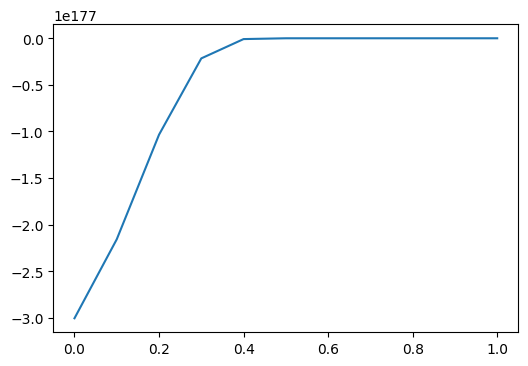

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
xx, y = DiffSweep(1, 0.1)
plt.plot(xx, y)

In [99]:
import sympy

def DiffSweep2(T, dx):
    num_steps = int(T/dx)
    xx = np.arange(num_steps+1)*dx
    e1 = np.exp(xx - 2*xx**2)
    e2 = np.exp(2*xx**2 - xx)

    a = np.empty(num_steps+1)
    a[0] = 1
    a2 = np.empty(num_steps+1)
    a2[0] = 1
    b = np.empty(num_steps+1)
    b[0] = 0

    x = sympy.symbols('x')

    for k in range(num_steps):
        d = sympy.solve(x - a[k] - dx*(8*e1[k+1]*x**2 + e2[k+1]), x)
        if (np.abs(d[0] - a[k])) < (np.abs(d[1] - a[k])):
            a[k+1] = sympy.re(d[0])
        else: 
            a[k+1] = sympy.re(d[1])

    for k in range(num_steps):
        a2[k+1] = a2[k] + dx*(8*e1[k]*(a2[k]**2) + e2[k])

    

    # v = np.empty(num_steps+1)
    # v[num_steps] = 

    return xx, a, a2, e1, e2

C:\Users\lliza\AppData\Local\Temp\ipykernel_21020\3326551521.py:26: RuntimeWarning: overflow encountered in scalar power
  a2[k+1] = a2[k] + dx*(8*e1[k]*(a2[k]**2) + e2[k])


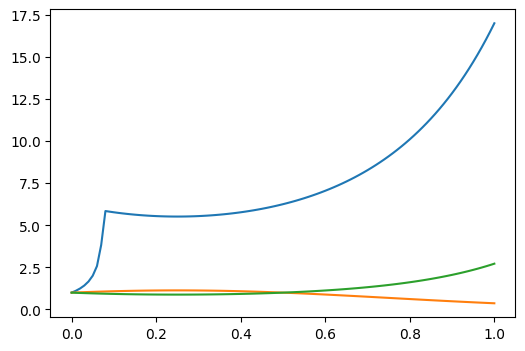

In [100]:
plt.figure(figsize=(6, 4))
xx, y, r, r1, e1 = DiffSweep2(1, 0.01)
plt.plot(xx, y)
#plt.plot(xx, r)
plt.plot(xx, r1)
plt.plot(xx, e1)

In [119]:
from sympy import symbols, Eq, Function, dsolve

x = symbols('x')
y = Function('y')
a = Function('a')
b = Function('b')

#dsolve(y(x).diff(x, 2) + (1-4*x)*y(x).diff(x) + 8*y(x) - 5, y(x), ics={y(x).diff(x).subs(x, 0): 0, y(1): 0})

#dsolve(a(x).diff(x) - 8*sympy.exp(x - 2*x**2)*(a(x))**2 - sympy.exp(2*x**2 - x), a(x), ics={a(0): 1})
dsolve(a(x).diff(x) - (a(x))**2, a(x), ics={a(0): 1})

Eq(a(x), -1/(x - 1))

In [122]:
dsolve(b(x).diff(x) + b(x)*(1/(x-1)) - 1/(x-1), b(x), ics={b(0): 0})

Eq(b(x), x/(x - 1))

Text(0.5, 1.0, 'alpha')

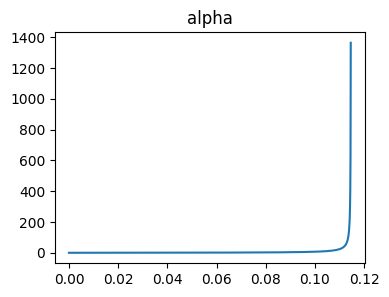

In [123]:
def fun(x, a):
    return a[0]**2#8*np.exp(x-2*x**2)*a**2 + np.exp(2*x**2 - x)
def fun2(x, a):
    return 8*np.exp(x-2*x**2)*a[0]**2 + np.exp(2*x**2 - x)

r_border = 0.99
xx = np.linspace(0, r_border, 10000)
bunch = scipy.integrate.solve_ivp(fun2, (0, r_border), y0=[1], t_eval=xx)
plt.figure(figsize=(4, 3))
xx = bunch.t
a = bunch.y[0]
plt.plot(xx, a)
plt.title('alpha')

array([0.00000000e+00, 9.90099010e-05, 1.98019802e-04, ...,
       1.14356436e-01, 1.14455446e-01, 1.14554455e-01])

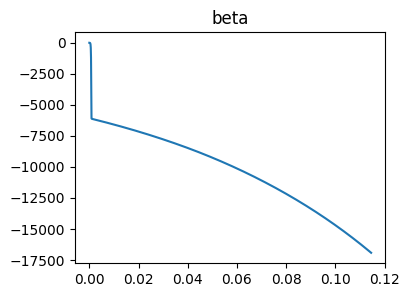

In [125]:
def funb(x, b):
    indx = int(((x/r_border) * np.size(xx))) - 1
    return 8*np.exp(x-2*x**2)*a[indx]*b[0] - 5*np.exp(-2*x**2 + x)*a[indx]

#xx = np.linspace(0, 0.99, 10000)
bunch = scipy.integrate.solve_ivp(funb, (0, r_border), y0=[0], t_eval=xx)
plt.figure(figsize=(4, 3))
xx = bunch.t
b = bunch.y[0]
plt.plot(xx, b)
plt.title('beta')

__Задание 2.__ 

Рассмотрим решение следующей граничной задачи

$$
\begin{gathered}
d^{2} y / d x^{2}=-y+x \cos x \\
\\
d y(0) / d x=3 y(0)+2, \quad d y(\pi / 2) / d x=-5 y(\pi / 2)+2 .
\end{gathered}
$$

Известно точное решение этой задачи

$$
y=-0.73 \cos x-0.441 \sin x+(1 / 4)\left(x^{2} \sin x+x \cos x\right),
$$

откуда

$$
y(\pi / 2)=0.175 \text { и } d y(\pi / 2) / d x=1.122 .
$$

Найдите эти граничные значения, решая задачу методом дифференциальной прогонки. 

In [91]:
from sympy import symbols, Eq, Function, dsolve
import sympy as sp
from IPython.display import display, Math
x, q, p, C1 = sp.symbols('x q p C1')
y = sp.Function('y')
a, b, c, g, v = sp.symbols('a b c g v', cls=Function)

# Type in your linear diff eq (De),
# and outnput is 3 differential equations on coefficients a, b, c, g
# для дифференциальной прогонки
De = y(x).diff(x, 2) + y(x) - x*sp.cos(x)
# ------------------------------------------------------------------------------------

Dyp = y(x).diff(x) - a(x)*v(x) - b(x)
Dvp = v(x).diff(x) - c(x)*y(x) - g(x)

yp = sp.solve(Dyp, y(x).diff(x))[0]
vp = sp.solve(Dvp, v(x).diff(x))[0]

ypp = sp.solve(Dyp.diff(x), y(x).diff(x, 2))[0]
ypp = ypp.subs(v(x).diff(x), vp)

Desubs = De.subs(y(x).diff(x, 2), ypp)
Desimp = sp.collect(sp.expand(Desubs), [y(x), v(x)])
E1 = Desimp.coeff(y(x))
E2 = Desimp.coeff(v(x))
E3 = Desimp - E1*y(x) - E2*v(x)
display(Desimp, E1, E2, E3)

-x*cos(x) + (a(x)*c(x) + 1)*y(x) + a(x)*g(x) + v(x)*Derivative(a(x), x) + Derivative(b(x), x)

a(x)*c(x) + 1

Derivative(a(x), x)

-x*cos(x) + a(x)*g(x) + Derivative(b(x), x)

In [92]:
# решить эти 3 уравнения и подставить выражения для a, b, c, g ниже
def a(x):
    return 1
def b(x):
    return 0
def c(x):
    return -1
def g(x):
    return x * sp.cos(x)
# ------------------------------------------------------------------------------------
# ввести начальные условия
ic1 = y(x).diff(x) - 3*y(x) - 2
ic2 = y(x).diff(x) + 5*y(x) - 2
x0 = 0; x1 = sp.pi/2
# ------------------------------------------------------------------------------------
ics = {ic1.subs(x, x0): 0, ic2.subs(x, x1): 0}

alpha, beta, v = sp.symbols('alpha beta v', cls=Function)

A = alpha(x).diff(x) + c(x)*(alpha(x))**2 - a(x)
B = beta(x).diff(x) + alpha(x)*beta(x)*c(x) + alpha(x)*g(x) - b(x)
V = v(x).diff(x) - alpha(x)*c(x)*v(x) - c(x)*beta(x) - g(x)

ysw = alpha(x)*v(x) + beta(x)
ic1_expand = ic1.subs(y(x).diff(x), a(x)*v(x) + b(x)).subs(y(x), ysw)
ic2_expand = ic2.subs(y(x).diff(x), a(x)*v(x) + b(x)).subs(y(x), ysw)

ic1Subs = ic1_expand.subs(x, x0)
ic2Subs = ic2_expand.subs(x, x1)
display("граничные условия:", sp.Eq(ic1Subs, 0), sp.Eq(ic2Subs, 0))

# решение граничных условий
alpha0, beta0 = list(sp.solve([ic1Subs.coeff(v(x).subs(x, x0)), (ic1Subs - v(0)*ic1Subs.coeff(v(x).subs(x, x0))).expand()], [alpha(x).subs(x, x0), beta(x).subs(x, x0)]).values())

alpha0, beta0

'граничные условия:'

Eq(-3*alpha(0)*v(0) - 3*beta(0) + v(0) - 2, 0)

Eq(5*alpha(pi/2)*v(pi/2) + 5*beta(pi/2) + v(pi/2) - 2, 0)

(1/3, -2/3)

In [93]:
alphax = dsolve(A, alpha(x), ics={alpha(x).subs(x, x0): alpha0}).rhs
betax = dsolve(B.subs(alpha(x), alphax), beta(x), ics={beta(x).subs(x, x0): beta0}).rhs
display(Math(r'\alpha(x)='), alphax, Math(r'\beta(x)='), betax)

<IPython.core.display.Math object>

tan(x + atan(1/3))

<IPython.core.display.Math object>

x**2*sin(x)/4 - x**2*cos(x)*tan(x + atan(1/3))/4 - x*sin(x)*tan(x + atan(1/3))/4 + x*cos(x)/4 - sqrt(10)*sqrt(tan(x + atan(1/3))**2 + 1)/5 - sin(x)/4

In [94]:
icsV = ic2Subs.subs(alpha(x).subs(x, x1), alphax.subs(x, x1)).subs(beta(x).subs(x, x1), betax.subs(x, x1))
vx1 = sp.solve(icsV, v(x).subs(x, x1))[0]
vx1 # граничное условие на v(x) справа
#dsolve(V.subs(alpha(x), alphax).subs(beta(x), betax), v(x), ics={v(x).subs(x, x1): vx1})


-53/56 + 5*pi**2/224 + 15*pi/112

-0.30537588565562235

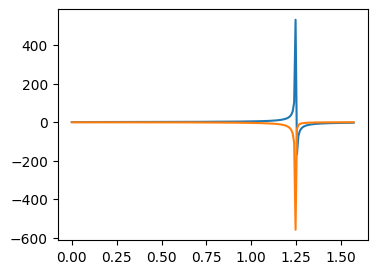

In [102]:
import numpy as np
import matplotlib.pyplot as plt
fa = sp.lambdify(x, alphax)
fb = sp.lambdify(x, betax)
xx = np.linspace(float(x0), float(x1), 200)
plt.figure(figsize=(4, 3))
plt.plot(xx, fa(xx))
plt.plot(xx, fb(xx))
float(vx1)

Text(0.5, 1.0, 'на этом промежутке решение близко к точному')

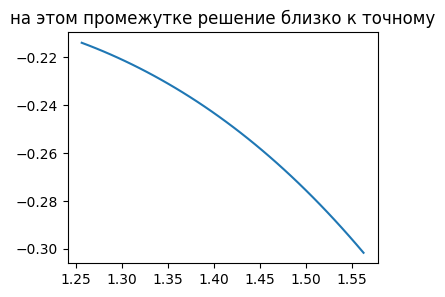

In [103]:
num_steps = 200

x0 = float(x0)
x1 = float(x1)
xx = np.linspace(x0, x1, num_steps+1)
dx = (x1 - x0)/num_steps

fa = sp.lambdify(x, alphax)
fb = sp.lambdify(x, betax)

def a(x):
    return 1
def b(x):
    return 0
def c(x):
    return -1
def g(x):
    return x * np.cos(x)

arr1 = fa(xx) * c(xx)
arr2 = fb(xx) * c(xx) + g(xx)

v = np.zeros(num_steps+1)
v[-1] = float(vx1)
for k in range(num_steps-1, -1, -1):
    v[k] = v[k+1] - dx*(arr1[k+1]*v[k+1] + arr2[k+1])

plt.figure(figsize=(4,3))
plt.plot(xx[160:-1], v[160:-1])
plt.title('на этом промежутке решение близко к точному')



In [101]:
alpha1 = alphax.subs(x, x1)
beta1 = betax.subs(x, x1)
y1 = alpha1*vx1 + beta1
float(y1)

0.46107517713112445

0.4610751771311241

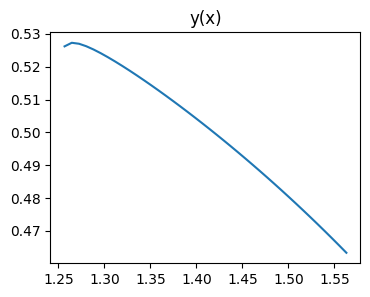

In [104]:
plt.figure(figsize=(4,3))
y = fa(xx)*v + fb(xx)
plt.plot(xx[160:-1], y[160:-1])
plt.title('y(x)')
y[-1]

In [110]:
ypr = (y[-1] - y[-3])/(2*dx)
display(Math(r'y_x(\pi/2)='), ypr)

<IPython.core.display.Math object>

-0.28639516832385076

In [230]:
# eqs = [Eq(E1, 0), Eq(E2, 0)]
# sp.dsolve(E2, a(x))
# sp.dsolve(E1.subs(a(x), C1), c(x))
# #sp.dsolve([E1, E2], [a(x), c(x)])
# #sp.dsolve([E1, E2, E3], [a(x), b(x), c(x)])

Eq(c(x), -1/C1)

__Задание 3.__ 

Напишите программу, которая решает нелинейное уравнение Пуассона:

$$
\phi^{\prime \prime}(x)=e^{\phi(x)}-n(x), \quad \text { где } n(x)=1+e^{-3(x-5)^{2}}  
$$

в области $0<=x<=10$ с граничными условиями $\phi(0)=\phi(10)=0 .$

__Примечание.__ Пользоваться методом стрельбы, сходясь по Ньютону. Сколько итераций нужно, чтобы получить решение с  10-ю значащими цифрами?

-14.749076806020966

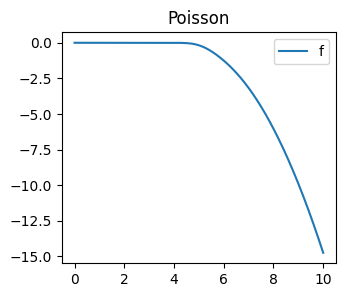

In [49]:
# пристрелка alpha = 0
import numpy as np
import matplotlib.pyplot as plt

def Poisson(T, dx, f0):
    f0 = np.asarray(f0, dtype=float)
    num_steps = int(T/dx)
    xx = np.arange(num_steps+1)*dx

    f = np.empty(num_steps+1)
    f[0] = f0[0]
    f[1] = f0[0] + dx*f0[1]

    for k in range(1, num_steps):
        f[k+1] = 2*f[k] - f[k-1] + dx**2 * (np.exp(f[k]) - 1 - np.exp(-3*(xx[k]-5)**2))

    return xx, f

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
xx, f = Poisson(10, 0.01, [0, 0])  #0.006518
plt.plot(xx, f, label="f")
plt.title('Poisson')
plt.legend()
f[-1]

In [68]:
# итерация по Ньютону
a = 0.006518
dx = 0.01
da = 0.0000001
xx, f = Poisson(10, dx, [0, a])

while (np.abs(f[-1]) > 0.000000000001):
    xx2, f2 = Poisson(10, dx, [0, a+da])
    fprime = (f2[-1] - f[-1])/da
    print(fprime, f2[-1], f[-1])
    
    a = a - (f[-1]/(fprime))
    xx, f = Poisson(10, dx, [0, a])

print(a)

17783.991487037863 0.006705390583811963 0.004926991435108176
17755.106683845377 0.001780958295650639 5.447627266101479e-06
17755.074810970375 0.0017755090781846577 1.597087620441255e-09
17755.07453707578 0.0017755074661876806 1.2480102899162554e-11
17755.074656360695 0.00177550746384753 -1.7885394655316824e-12
17755.07461364772 0.0017755074649376354 3.5728633382591475e-12
17755.0746609455 0.0017755074632756964 -2.8188538736713424e-12
17755.074597220355 0.0017755074632656363 3.543600843704869e-12
17755.07461027145 0.0017755074560895244 -4.9376205646718795e-12
17755.074602954348 0.0017755074638426168 3.547182047701637e-12
17755.074648026253 0.0017755074613603867 -3.4422385014429904e-12
17755.074603002737 0.0017755074638473396 3.547066124284562e-12
17755.074642568063 0.0017755074594583975 -4.79840866086239e-12
17755.074606959977 0.0017755074642535472 3.55754942423347e-12
17755.074650658593 0.0017755074632773197 -1.7885394655316824e-12
17755.074604040437 0.0017755074639476446 3.54360084370

-5.900517370705084e-13

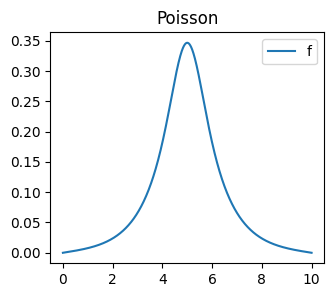

In [66]:
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
xx, f = Poisson(10, 0.01, [0, 0.006517722646654366])
plt.plot(xx, f, label="f")
plt.title('Poisson')
plt.legend()
f[-1]

__Задание 4.__ 

Напишите программу, которая решает нелинейное уравнение Пуассона:

$$
\phi^{\prime \prime}(x)=e^{\phi(x)}-n(x), \quad \text { где } n(x)=1+e^{-3(x-5)^{2}}  
$$

в области $0<=x<=10$ с граничными условиями $\phi(0)=\phi(10)=0 .$


Используйте метод Ньютона (не стрельбы!1!!). Сколько итераций нужно, чтобы получить решение с  10-ю значащими цифрами?

Text(0.5, 1.0, 'Первая поправка')

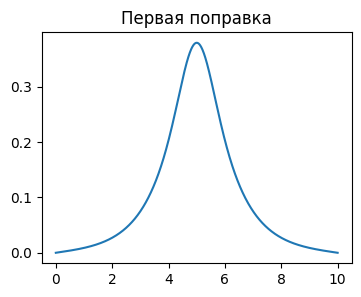

In [91]:
import sympy as sp
v = sp.Function('v')
w = sp.Function('w')
x = sp.symbols('x')

vx = sp.dsolve(v(x).diff(x, 2) - v(x) + sp.exp(-3*(x-5)**2), v(x), ics={v(x).subs(x, 0): 0, v(x).subs(x, 10): 0}).rhs
funcV = sp.lambdify(x, vx)

xx = np.linspace(0, 10, 1000)
plt.figure(figsize=(4,3))
vv = funcV(xx)
plt.plot(xx, vv)
plt.title('Первая поправка')

Text(0.5, 1.0, '$v_{xx}$')

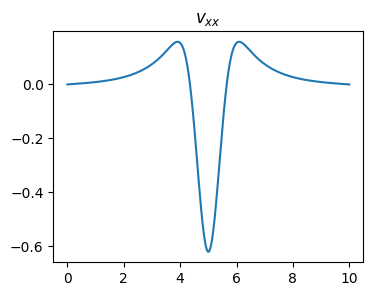

In [92]:
#wx = sp.dsolve(w(x).diff(x, 2) - (w(x) + 1)*sp.exp(v(x)) + 1 + sp.exp(-3*(x-5)**2) + v(x).diff(x, 2), w(x), ics={w(x).subs(x, 0): 0, w(x).subs(x, 10): 0}).rhs
#funcW = sp.lambdify(x, wx)
vxpp = sp.lambdify(x, vx.diff(x, 2))
plt.figure(figsize=(4,3))
plt.plot(xx, vxpp(xx))
plt.title('$v_{xx}$')

In [107]:
import scipy
num_steps = 1000
xx = np.linspace(0, 10, num_steps)

def n(x):
    return 1 + np.exp(-3*(x-5)**2)

vv = funcV(xx)
vpp = vxpp(xx)
nn = n(xx)
ev = np.exp(vv)
#initial guess
y0 = np.zeros((2, num_steps))

def A(k):
    #k = int((x/10)*num_steps)
    return np.array([[0, 1], [ev[k], 0]])
#k = np.arange(0, 1000)
#A = np.array([[0, 1], [ev[k], 0]])

def fun(x, y):
    arr = np.zeros((2, np.size(x)))
    for i in x:
        k = int((i/10)*num_steps)
        yi = y[:, k]
        arr1d = A(k)@yi + np.array([0, ev[k] - nn[k] - vpp[k]])
        arr[:,k] = arr1d
    return arr

def bc(ya, yb):
    return np.array([ya[0], yb[0]])

scipy.integrate.solve_bvp(fun, bc, xx, y0)

IndexError: index 1000 is out of bounds for axis 0 with size 1000

In [103]:
k = np.arange(0, 1000)
A = np.array([[0, 1], [ev[k], 0]])
f = np.array

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.

__Задание 5.__

Методом Ньютона с использованием проекционного решения найти первые два приближения к решению краевой задачи. 

Сравнить приближенное решение с точным. Оценить относительную погрешность решения.

На выбор можете взять любой проекционный метод, кроме разложения по синусам и косинусам в методе Галёркина. 

Номер вашей задачи - это $(B \mod 12) + 1$, где B - номер первой буквы вашей фамилии в алфавите. 

1) $-\ddot{x}=-\dot{x} /(1+t)+\dot{x}^2 / x, x(0)=2, x(1)=1$

Точное решение: $x^*(t)=\left[5-(1+t)^2\right]^{1 / 2}$.

2) $\ddot{x}=\left(\dot{x}^2+1\right)^{3 / 2}, x(0)=-1, x(1)=0$. 

Точное решение: $x^*(t)=-\left(1-t^2\right)^{1 / 2}$.

3) $\ddot{x}=x^3, \quad x(0)=\sqrt{2}, x(1)=1 / \sqrt{2}$. 

Точное решение: $x^*(t)=\sqrt{2} /(1+t)$.

4) $-\ddot{x}=-\left(\dot{x}^2+1\right) /\left(1+t^2\right), x(0)=0, x(1)=-1 / 2$.

Точное решение: $x^*(t)=-t^2 / 2$.

5) $-\ddot{x}+10 t^{-5} x^2=4 t, x(1)=1, x(2)=8$. 

Точное решение: $x^*(t)=t^3$.

6) $-\ddot{x}+2 t^{-10} x^3=-10 t^2, x(1)=1, x(2)=32$.

Точное решение: $x^*(t)=t^4$.

7) $\ddot{x}=-4 x^{-3}, x(0)=2, x(1)=\sqrt{3}$. 

Точное решение: $x^*(t)=\sqrt{4-t^2}$.

8) $\ddot{x}=2 x^3, x(0)=1 / 2, x(1)=1 / 3$. 

Точное решение: $x^*(t)=1 /(2+t)$.

9) $\ddot{x}=-25 x^{-3}, x(0)=4, x(1)=3$. 

Точное решение: $x^*(t)=\sqrt{25-(3+t)^2}$.

10) $-\ddot{x}=x^3-3 t^2 x^5, x(2)=1 / \sqrt{3}, x(3)=1 / \sqrt{8}$.

Точное решение: $x^*(t)=1 / \sqrt{t^2-1}$


11) $\ddot{x}=12 t x^2, x(1)=1, x(2)=1 / 8$. 

Точное решение: $x^*(t)=t^{-3}$.

12) $\ddot{x}=20 t^2 x^2, x(1)=1, x(2)=1 / 16$. 

Точное решение: $x^*(t)=t^{-4}$. 

In [43]:
from scipy.integrate import quad
import numpy as np

def fjk(t, k, j):
    fk = -((np.pi*k)**2)*np.sin(np.pi*k*t) - 3*np.sqrt(2)*np.pi*k*np.cos(np.pi*k*t)
    fj = -((np.pi*j)**2)*np.sin(np.pi*j*t) - 3*np.sqrt(2)*np.pi*j*np.cos(np.pi*j*t)
    return fk*fj

def frhs(t, j):
    fj = -((np.pi*j)**2)*np.sin(np.pi*j*t) - 3*np.sqrt(2)*np.pi*j*np.cos(np.pi*j*t)
    return 2**(3/2) * fj

N = 13
Akj = np.zeros((N, N))
for k in range(N):
    for j in range(N):
        Akj[k][j] = quad(fjk, 0, 1, (k+1, j+1))[0]

Gj = np.zeros(N)
for j in range(N):
    Gj[j] = quad(frhs, 0, 1, j+1)[0]

Text(0.5, 1.0, 'первая поправка')

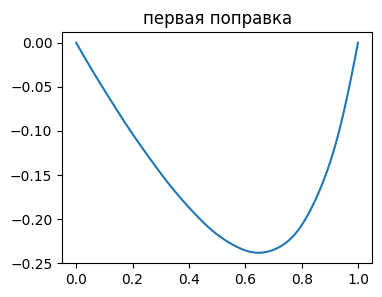

In [44]:
import scipy
import matplotlib.pyplot as plt

ak = scipy.linalg.solve(Akj, Gj)
def v(t):
    vt = 0
    for k in range(1, N+1):
        vt += ak[k-1]*np.sin(np.pi*k*t)
    return vt

tt = np.linspace(0, 1, 100)
plt.figure(figsize=(4, 3))
plt.plot(tt, v(tt))
plt.title('первая поправка')

Text(0.5, 1.0, '$v_t$')

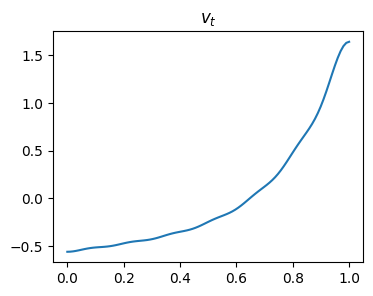

In [45]:
def vp(t):
    vtp = 0
    for k in range(1, N+1):
        vtp += ak[k-1]*np.pi*k*np.cos(np.pi*k*t)
    return vtp

tt = np.linspace(0, 1, 100)
plt.figure(figsize=(4, 3))
plt.plot(tt, vp(tt))
plt.title('$v_t$')

In [46]:
# вторая поправка

def fjk(t, k, j):
    qt = - 3 * ((1 + vp(t))**2 + 1)**(1/2) * (1 + vp(t))
    fk = -((np.pi*k)**2)*np.sin(np.pi*k*t) + qt*np.pi*k*np.cos(np.pi*k*t)
    fj = -((np.pi*j)**2)*np.sin(np.pi*j*t) + qt*np.pi*j*np.cos(np.pi*j*t)
    return fk*fj

def frhs(t, j):
    qt = - 3 * ((1 + vp(t))**2 + 1)**(1/2) * (1 + vp(t))
    gt = 2**(3/2) + 3*np.sqrt(2)*vp(t) - ((1+vp(t))**2 + 1)**(3/2)
    fj = -((np.pi*j)**2)*np.sin(np.pi*j*t) + qt*np.pi*j*np.cos(np.pi*j*t)
    return - gt * fj

N = 13
Akj = np.zeros((N, N))
for k in range(N):
    for j in range(N):
        Akj[k][j] = quad(fjk, 0, 1, (k+1, j+1))[0]

Gj = np.zeros(N)
for j in range(N):
    Gj[j] = quad(frhs, 0, 1, j+1)[0]

Text(0.5, 1.0, 'вторая поправка')

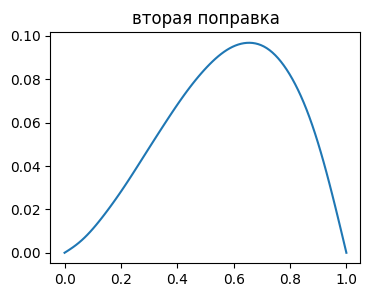

In [47]:
ak = scipy.linalg.solve(Akj, Gj)
def w(t):
    wt = 0
    for k in range(1, N+1):
        wt += ak[k-1]*np.sin(np.pi*k*t)
    return wt

tt = np.linspace(0, 1, 100)
plt.figure(figsize=(4, 3))
plt.plot(tt, w(tt))
plt.title('вторая поправка')

Text(0.5, 1.0, 'решение (сделана одна поправка)')

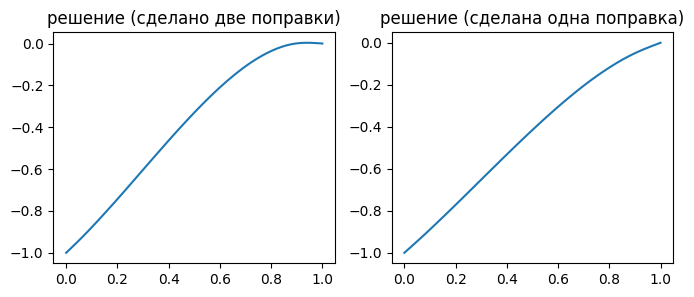

In [52]:
tt = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(tt, tt - 1 + v(tt) + w(tt))
plt.title('решение (сделано две поправки)')

plt.subplot(1, 2, 2)
plt.plot(tt, tt - 1 + v(tt))
plt.title('решение (сделана одна поправка)')

Text(0.5, 1.0, 'точное решение')

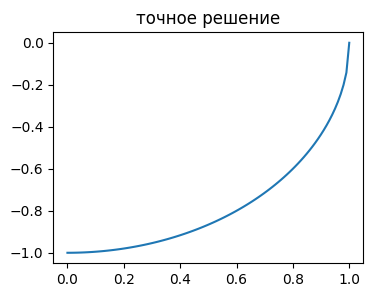

In [50]:

def f(t):
    return - np.sqrt(1 - t**2)

tt = np.linspace(0, 1, 100)
plt.figure(figsize=(4, 3))
plt.plot(tt, f(tt))
plt.title('точное решение')